In [ ]:
# === auto-inserted: bev-solving src on path ===
import sys, pathlib
_root = pathlib.Path.cwd()
while _root != _root.parent and not (_root / 'src' / 'geometry.py').exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


# Post-train evaluation + submission

Standalone ноутбук для всего что делается ПОСЛЕ обучения. Не зависит от состояния трейн-сессии.

Что делает:
1. Загружает best.pt / ema.pt из `runs/{RUN_NAME}/`
2. **Streaming threshold sweep** на validation (не кеширует логиты — нет OOM)
3. Inference на test с лучшим threshold
4. Сборка submission zip с проверкой и SHA256

Можешь использовать после любого запуска train_v1 / train_v2.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

from bev_v1 import iou_binary_batch, BEV_H, BEV_W
from bev_v3 import BEVDatasetAug, make_group_aware_split

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"device = {device}")

DATA_TRAIN = Path("./autonomy_yandex_dataset_train/")
DATA_VAL = Path("./autonomy_yandex_dataset_val/")
DATA_TEST = Path("./autonomy_yandex_dataset_test/")

device = cuda


## 1. Конфиг — какой checkpoint и какой preset использовать

In [2]:
# Что грузим
RUN_DIR = Path("./runs/bev_v3_a100_phase2")  # ← поправь под свой run
WHICH_CKPT = "ema"   # "best" | "ema" | "last"
MODEL_TYPE = "v2"     # "v1" — MultiCamBEV; "v2" — MultiCamBEVPretrainedEncoder

# Параметры данных (как при обучении)
IMG_HW = (448, 800)   # ← поправь если другой preset
BATCH = 4             # для inference; уменьши если OOM
NUM_WORKERS = 4
USE_AMP = True

# Какой val использовать для threshold sweep
USE_GROUP_SPLIT_VAL = True  # True — group-holdout из train (как в train_v2);
                            # False — официальный val

ckpt_path = RUN_DIR / f"{WHICH_CKPT}.pt"
assert ckpt_path.exists(), f"checkpoint not found: {ckpt_path}"
print(f"Loading {ckpt_path}")

Loading runs/bev_v3_a100_phase2/ema.pt


In [3]:
# Загружаем модель
if MODEL_TYPE == "v1":
    from bev_v1 import MultiCamBEV
    model = MultiCamBEV(freeze_backbone=False)
elif MODEL_TYPE == "v2":
    from bev_v2 import MultiCamBEVPretrainedEncoder
    model = MultiCamBEVPretrainedEncoder(load_pretrained=False, freeze_encoder=False)
else:
    raise ValueError(MODEL_TYPE)

ckpt = torch.load(ckpt_path, map_location=device)
missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
print(f"  missing keys: {len(missing)}")
print(f"  unexpected keys: {len(unexpected)}")
model = model.to(device).eval()

print(f"\nCheckpoint info:")
for k in ("epoch", "val_iou", "ema_val_iou", "official_val_iou", "preset", "which"):
    if k in ckpt:
        print(f"  {k}: {ckpt[k]}")
n_params = sum(p.numel() for p in model.parameters())
print(f"  total params: {n_params/1e6:.2f}M")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/xdg_cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 50.9MB/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /tmp/xdg_cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:02<00:00, 66.3MB/s]

  missing keys: 0
  unexpected keys: 0

Checkpoint info:
  epoch: 25
  val_iou: 0.5586317725279389
  total params: 39.01M


## 2. Готовим val loader

Если `USE_GROUP_SPLIT_VAL=True` — используем тот же group split что был при обучении (кэш в `runs/{RUN_NAME}/group_split.npz`).

In [4]:
if USE_GROUP_SPLIT_VAL:
    # Используем тот же group split — берём из кеша если есть
    cache = RUN_DIR / "group_split.npz"
    if cache.exists():
        print(f"Using cached group split: {cache}")
    else:
        print(f"Cache не найден ({cache}) — пересчитаю group split с тем же seed.")
    train_idx, val_idx = make_group_aware_split(
        DATA_TRAIN / "info.csv",
        group_cols=("rover", "ride_date"),
        holdout_frac=0.2, seed=42,
        cache_path=cache,
    )
    val_ds_full = BEVDatasetAug(DATA_TRAIN, mode="val", img_hw=IMG_HW, aug=False)
    val_ds = Subset(val_ds_full, val_idx)
else:
    val_ds = BEVDatasetAug(DATA_VAL, mode="val", img_hw=IMG_HW, aug=False)

val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
print(f"val samples: {len(val_ds)}, batches: {len(val_loader)}")

Using cached group split: runs/bev_v3_a100_phase2/group_split.npz
val samples: 958, batches: 240


## 3. Streaming threshold sweep (без OOM)

Идея: вместо кеширования всех логитов — **проходим по батчам один раз** и для каждого порога обновляем counters (inter, union). Это требует одной inference-сессии и **постоянной памяти** независимо от размера val.

In [ ]:
from src.metrics import streaming_threshold_sweep

thresholds = np.linspace(0.20, 0.70, 26).tolist()  # 26 точек, шаг 0.02
iou_by_t = streaming_threshold_sweep(
    model, val_loader, thresholds=thresholds, device=device, amp_enabled=USE_AMP,
)

best_t, best_iou = max(iou_by_t.items(), key=lambda kv: kv[1])
print(f"\nBest threshold: {best_t:.3f}  IoU = {best_iou:.4f}")
print("\nFull sweep:")
for t, iou in iou_by_t.items():
    marker = " ← best" if t == best_t else ""
    print(f"  t={t:.3f}  IoU={iou:.4f}{marker}")


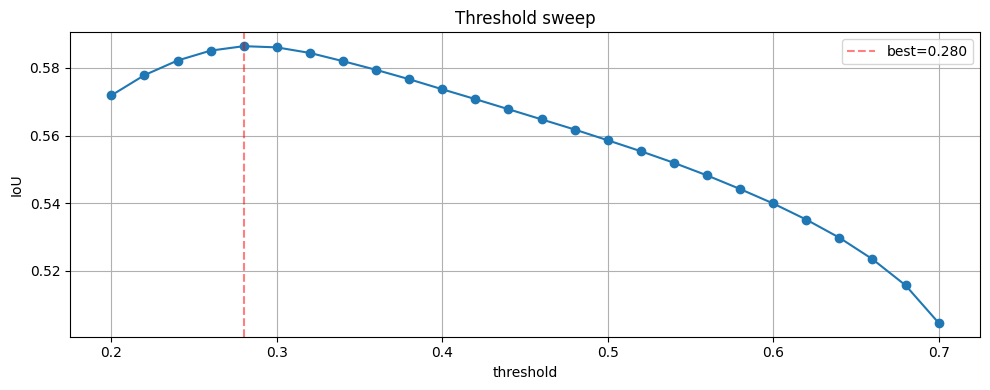

In [6]:
# Plot sweep
ts = list(iou_by_t.keys())
ious = [iou_by_t[t] for t in ts]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts, ious, marker="o")
ax.axvline(best_t, color="red", linestyle="--", alpha=0.5, label=f"best={best_t:.3f}")
ax.set_xlabel("threshold"); ax.set_ylabel("IoU")
ax.set_title("Threshold sweep"); ax.grid(); ax.legend()
plt.tight_layout(); plt.show()

## 4. Также прогнать по официальному val для сравнения

Просто чтобы понять: насколько group-split val ≈ test distribution. Если на group-split IoU выше чем на official — значит официальный сложнее, и то что мы тренировали с group-split val было правильным выбором.

In [7]:
if USE_GROUP_SPLIT_VAL:
    # Дополнительно прогоним по официальному val
    official_ds = BEVDatasetAug(DATA_VAL, mode="val", img_hw=IMG_HW, aug=False)
    official_loader = DataLoader(official_ds, batch_size=BATCH, shuffle=False,
                                 num_workers=NUM_WORKERS)
    iou_official = streaming_threshold_sweep(
        model, official_loader, thresholds=[best_t], device=device, amp_enabled=USE_AMP,
    )
    print(f"Group-split val IoU @ t={best_t}: {best_iou:.4f}")
    print(f"Official val IoU   @ t={best_t}: {iou_official[best_t]:.4f}")
else:
    print("Используется официальный val — пропускаем дополнительную проверку.")

streaming sweep: 100%|██████████| 250/250 [01:26<00:00,  2.87it/s]

Group-split val IoU @ t=0.28: 0.5865
Official val IoU   @ t=0.28: 0.5467


## 5. Inference на test

In [12]:
# Опционально: переопределить threshold (если хочешь использовать не best, а 0.5)
INFER_THRESHOLD = 0.75  # или поставь 0.5 / 0.45 / etc
print(f"Using threshold = {INFER_THRESHOLD}")

test_ds = BEVDatasetAug(DATA_TEST, mode="test", img_hw=IMG_HW, aug=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                         num_workers=NUM_WORKERS)
test_info = pd.read_csv(DATA_TEST / "info.csv", index_col=0)
(DATA_TEST / "predicted_static_grids").mkdir(exist_ok=True)

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="test inference"):
        images = batch["images"].to(device, non_blocking=True)
        intr = batch["intrinsics"].to(device, non_blocking=True)
        c2c = batch["car2cams"].to(device, non_blocking=True)
        idxs = batch["info_idx"]
        with torch.cuda.amp.autocast(enabled=USE_AMP and device.type == "cuda"):
            logits = model(images, intr, c2c).float()
        preds = (torch.sigmoid(logits) > INFER_THRESHOLD).cpu().numpy().astype(np.int32)
        for k, i in enumerate(idxs):
            out_path = test_info.iloc[i.item()]["predicted_occupancy_grid"]
            grid = preds[k].reshape(1, BEV_H, BEV_W)
            np.save(out_path, grid)
print("all predictions saved")

Using threshold = 0.75


test inference: 100%|██████████| 500/500 [03:14<00:00,  2.56it/s]

all predictions saved


## 6. Submission packing (надёжный)

In [13]:
import zipfile, hashlib

SUBMISSION_NAME = f"submission_{RUN_DIR.name}_{WHICH_CKPT}_075.zip"

# Pre-check
missing, shape_bad = [], []
for i, row in test_info.iterrows():
    p = Path(row["predicted_occupancy_grid"])
    if not p.exists():
        missing.append(str(p))
        continue
    arr = np.load(p)
    if arr.shape != (1, BEV_H, BEV_W) or set(np.unique(arr).tolist()) - {0, 1}:
        shape_bad.append(str(p))
if missing or shape_bad:
    print(f"!! missing: {len(missing)}, shape_bad: {len(shape_bad)}")
    print(f"   first missing: {missing[:3]}")
    print(f"   first shape_bad: {shape_bad[:3]}")
    raise RuntimeError("Не все предсказания корректны — заново запусти клетку inference")
print(f"OK: {len(test_info)} predictions valid")

# Build zip
sub_path = Path(SUBMISSION_NAME)
if sub_path.exists():
    sub_path.unlink()
with zipfile.ZipFile(sub_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    zf.write(DATA_TEST / "info.csv", arcname="info.csv")
    for npy in sorted((DATA_TEST / "predicted_static_grids").glob("*.npy")):
        zf.write(npy, arcname=f"predicted_static_grids/{npy.name}")

# Verify
with zipfile.ZipFile(sub_path, "r") as zf:
    bad = zf.testzip()
    assert bad is None, f"Bad zip entry: {bad}"
    n_entries = len(zf.namelist())

# Hash
h = hashlib.sha256()
with open(sub_path, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
size_mb = sub_path.stat().st_size / 1e6

print(f"\n=== SUBMISSION ===")
print(f"  path:    {sub_path.resolve()}")
print(f"  entries: {n_entries}")
print(f"  size:    {size_mb:.2f} MB")
print(f"  sha256:  {h.hexdigest()}")
print(f"  used:    threshold={INFER_THRESHOLD}, ckpt={WHICH_CKPT}, run={RUN_DIR.name}")

OK: 2000 predictions valid

=== SUBMISSION ===
  path:    /home/jupyter/project/submission_bev_v3_a100_phase2_ema_075.zip
  entries: 2001
  size:    1.80 MB
  sha256:  d034ff87bddb5b782fc4ef46f8d88b95df4c67f8c5c36ffb7544b6bfb6545a12
  used:    threshold=0.75, ckpt=ema, run=bev_v3_a100_phase2


## 7. Бонус: сравнить best vs ema vs last

Если хочешь понять какой checkpoint реально лучший — прогони этот блок, сравнит все три на одном threshold.

In [8]:
compare_thresholds = [0.4, 0.5, best_t]

for ckpt_name in ["best", "ema", "last"]:
    p = RUN_DIR / f"{ckpt_name}.pt"
    if not p.exists():
        print(f"skip {ckpt_name} — no file")
        continue
    c = torch.load(p, map_location=device)
    if MODEL_TYPE == "v1":
        from bev_v1 import MultiCamBEV
        m = MultiCamBEV(freeze_backbone=False)
    else:
        m = MultiCamBEVPretrainedEncoder(load_pretrained=False, freeze_encoder=False)
    m.load_state_dict(c["model"], strict=False)
    m = m.to(device).eval()
    iou_dict = streaming_threshold_sweep(
        m, val_loader, thresholds=compare_thresholds, device=device, amp_enabled=USE_AMP,
    )
    line = f"  {ckpt_name:6s}: "
    for t in compare_thresholds:
        line += f"t={t:.3f}→{iou_dict[t]:.4f}  "
    print(line)
    del m
    torch.cuda.empty_cache() if device.type == "cuda" else None

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
streaming sweep: 100%|██████████| 240/240 [01:25<00:00,  2.79it/s]

  best  : t=0.400→0.5910  t=0.500→0.5874  t=0.380→0.5912  



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
streaming sweep: 100%|██████████| 240/240 [01:25<00:00,  2.80it/s]


  ema   : t=0.400→0.5737  t=0.500→0.5586  t=0.380→0.5767  


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
streaming sweep: 100%|██████████| 240/240 [01:24<00:00,  2.84it/s]


  last  : t=0.400→0.5873  t=0.500→0.5814  t=0.380→0.5881  


v1 loaded from bev_v1_ckpt.pt


eval: 100%|██████████| 250/250 [02:34<00:00,  1.62it/s]



=== Overall IoU @ threshold=0.5 ===
  v1: 0.4553
  v3: 0.4401
  Δ:  -0.0152  (v3 - v1)

=== Per-distance IoU ===
      0-50m: v1=0.5359  v3=0.5125  Δ=-0.0234
    50-100m: v1=0.4515  v3=0.4296  Δ=-0.0219
   100-150m: v1=0.4000  v3=0.4037  Δ=+0.0037

=== Top 10 групп где v3 ХУЖЕ v1 ===
                    n        v1        v3     delta
rover   ride_date                                  
lucky   2023-03-09  4  0.700909  0.244137 -0.456772
stelard 2025-02-15  1  0.501219  0.133333 -0.367885
susana  2025-01-10  1  0.708308  0.359055 -0.349253
repara  2025-01-04  2  0.659025  0.328416 -0.330609
lucky   2023-02-14  4  0.507456  0.177523 -0.329933
hetera  2024-06-01  1  0.521972  0.194170 -0.327802
vittor  2025-03-18  1  0.631507  0.312873 -0.318634
anabel  2024-11-13  1  0.546875  0.236422 -0.310453
shelly  2021-12-29  2  0.565154  0.266056 -0.299097
arlim   2023-02-13  8  0.499601  0.201751 -0.297850

=== Top 10 групп где v3 ЛУЧШЕ v1 ===
                   n        v1        v3     delta
r

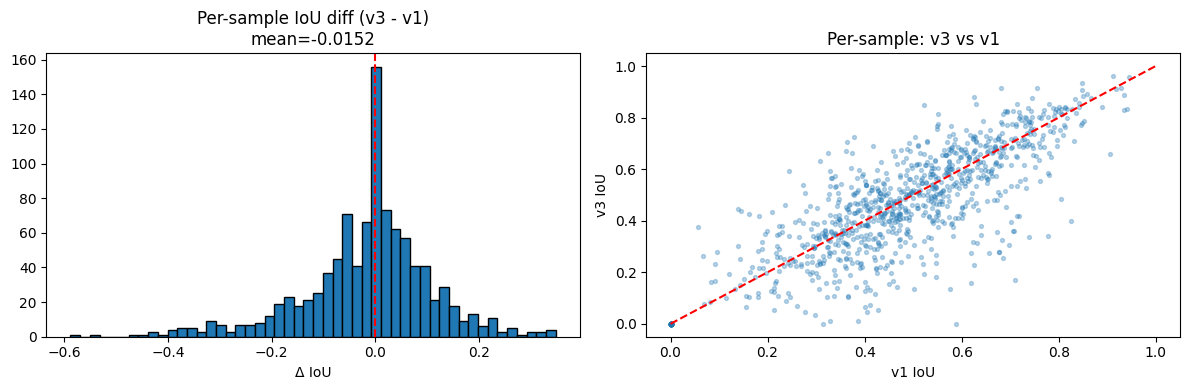

In [14]:
# ============ v1 vs v3 comparison on val ============
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm
from bev_v1 import MultiCamBEV, BEVDataset

V1_CKPT = "bev_v1_ckpt.pt"
V3_MODEL = model       # уже загруженная v3 модель
EVAL_BATCH = 4
THRESHOLD = 0.5

# --- 1. Загружаем v1 ---
v1 = MultiCamBEV(freeze_backbone=False).to(device).eval()
sd = torch.load(V1_CKPT, map_location=device)
sd = sd.get("model", sd.get("state_dict", sd))
v1.load_state_dict(sd, strict=False)
print(f"v1 loaded from {V1_CKPT}")

# --- 2. Eval loader (официальный val, info нужен для группировки) ---
DATA_VAL = Path("./autonomy_yandex_dataset_val/")
val_ds = BEVDataset(DATA_VAL, mode="val", img_hw=IMG_HW)
info = pd.read_csv(DATA_VAL / "info.csv", index_col=0).reset_index(drop=True)
val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH, shuffle=False, num_workers=2)

# --- 3. Per-sample IoU + per-distance breakdown ---
# 3 distance bands вдоль X (forward): [0..50м], [50..100м], [100..150м]
# X в нашем grid идёт по строкам (BEV_H=188), 0.8 м/пикс → bands = (0..63), (63..125), (125..188)
BANDS = [(0, 63, "0-50m"), (63, 125, "50-100m"), (125, 188, "100-150m")]

def per_sample_iou(prob, gt, threshold=0.5, ignore=255):
    # prob, gt: (B, 1, H, W); returns (B,) IoU + per-band (B, 3)
    valid = (gt != ignore)
    pred = ((prob > threshold) & valid).float()
    gt_b = ((gt == 1) & valid).float()
    out = []
    bands_iou = []
    for b in range(prob.shape[0]):
        p, g = pred[b, 0], gt_b[b, 0]
        i = (p * g).sum().item()
        u = ((p + g).clamp(0, 1)).sum().item()
        out.append(i / max(u, 1.0))
        row = []
        for x0, x1, _ in BANDS:
            pi = p[x0:x1]; gi = g[x0:x1]
            ii = (pi * gi).sum().item()
            uu = ((pi + gi).clamp(0, 1)).sum().item()
            row.append(ii / max(uu, 1.0) if uu > 0 else np.nan)
        bands_iou.append(row)
    return np.array(out), np.array(bands_iou)

@torch.no_grad()
def run_model(m, loader):
    m.eval()
    iou_all, band_all, idx_all = [], [], []
    for batch in tqdm(loader, desc=f"eval"):
        imgs = batch["images"].to(device)
        intr = batch["intrinsics"].to(device)
        c2c  = batch["car2cams"].to(device)
        gt   = batch["gt"]
        with torch.amp.autocast(device_type="cuda" if device=="cuda" else "cpu", enabled=(device=="cuda")):
            logits = m(imgs, intr, c2c)
        prob = torch.sigmoid(logits).float().cpu()
        iou, bands = per_sample_iou(prob, gt, THRESHOLD)
        iou_all.append(iou); band_all.append(bands)
        idx_all.extend(batch["info_idx"].tolist())
    return np.concatenate(iou_all), np.concatenate(band_all), idx_all

iou_v1, bands_v1, idx_v1 = run_model(v1, val_loader)
iou_v3, bands_v3, idx_v3 = run_model(V3_MODEL, val_loader)
assert idx_v1 == idx_v3

# --- 4. Сводка ---
print("\n=== Overall IoU @ threshold=0.5 ===")
print(f"  v1: {iou_v1.mean():.4f}")
print(f"  v3: {iou_v3.mean():.4f}")
print(f"  Δ:  {(iou_v3 - iou_v1).mean():+.4f}  (v3 - v1)")

print("\n=== Per-distance IoU ===")
for k, (_, _, name) in enumerate(BANDS):
    v1m = np.nanmean(bands_v1[:, k])
    v3m = np.nanmean(bands_v3[:, k])
    print(f"  {name:>9}: v1={v1m:.4f}  v3={v3m:.4f}  Δ={v3m-v1m:+.4f}")

# --- 5. Per-(rover, ride_date) breakdown ---
df = pd.DataFrame({
    "info_idx": idx_v1,
    "iou_v1": iou_v1,
    "iou_v3": iou_v3,
})
df["rover"] = df["info_idx"].map(info["rover"])
df["ride_date"] = df["info_idx"].map(info["ride_date"])
df["delta"] = df["iou_v3"] - df["iou_v1"]

grp = df.groupby(["rover", "ride_date"]).agg(
    n=("iou_v1", "size"),
    v1=("iou_v1", "mean"),
    v3=("iou_v3", "mean"),
    delta=("delta", "mean"),
).sort_values("delta")

print(f"\n=== Top 10 групп где v3 ХУЖЕ v1 ===")
print(grp.head(10).to_string())
print(f"\n=== Top 10 групп где v3 ЛУЧШЕ v1 ===")
print(grp.tail(10).to_string())

print(f"\n=== Сколько групп где v3 лучше / хуже / равны ===")
print(f"  v3 > v1: {(grp['delta'] > 0.005).sum()}")
print(f"  v3 < v1: {(grp['delta'] < -0.005).sum()}")
print(f"  ~равны:  {(grp['delta'].abs() <= 0.005).sum()}")

# --- 6. Распределение per-sample diff ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["delta"], bins=50, edgecolor="black")
ax[0].axvline(0, color="red", linestyle="--")
ax[0].set_title(f"Per-sample IoU diff (v3 - v1)\nmean={df['delta'].mean():+.4f}")
ax[0].set_xlabel("Δ IoU")
ax[1].scatter(df["iou_v1"], df["iou_v3"], alpha=0.3, s=8)
ax[1].plot([0, 1], [0, 1], "r--")
ax[1].set_xlabel("v1 IoU"); ax[1].set_ylabel("v3 IoU")
ax[1].set_title("Per-sample: v3 vs v1")
plt.tight_layout(); plt.show()


In [15]:
# ============ Ensemble v1 + v3 ============
@torch.no_grad()
def run_ensemble(m1, m3, loader, weight_v1=0.5, weight_v3=0.5, threshold=0.5):
    m1.eval(); m3.eval()
    iou_all, band_all = [], []
    for batch in tqdm(loader, desc="ensemble eval"):
        imgs = batch["images"].to(device); intr = batch["intrinsics"].to(device)
        c2c = batch["car2cams"].to(device); gt = batch["gt"]
        with torch.amp.autocast(device_type="cuda" if device=="cuda" else "cpu", enabled=(device=="cuda")):
            p1 = torch.sigmoid(m1(imgs, intr, c2c)).float().cpu()
            p3 = torch.sigmoid(m3(imgs, intr, c2c)).float().cpu()
        prob = weight_v1 * p1 + weight_v3 * p3
        iou, bands = per_sample_iou(prob, gt, threshold)
        iou_all.append(iou); band_all.append(bands)
    return np.concatenate(iou_all), np.concatenate(band_all)

# Попробуй несколько весов
print("=== Ensemble sweep на официальном val (threshold=0.5) ===")
for w in [(1.0, 0.0), (0.7, 0.3), (0.5, 0.5), (0.3, 0.7), (0.0, 1.0)]:
    iou_e, _ = run_ensemble(v1, V3_MODEL, val_loader, w[0], w[1], 0.5)
    print(f"  w_v1={w[0]:.1f} w_v3={w[1]:.1f} → IoU = {iou_e.mean():.4f}")

# Distance-aware ensemble: v1 weight выше на 0-50m, v3 на 100-150m
@torch.no_grad()
def run_distance_aware(m1, m3, loader, threshold=0.5):
    m1.eval(); m3.eval()
    # Вес v1 по строкам X (0..188): высокий на 0-63, средний 63-125, низкий 125-188
    w_v1_per_row = torch.linspace(0.7, 0.3, BEV_H).view(1, 1, BEV_H, 1)
    w_v3_per_row = 1.0 - w_v1_per_row
    iou_all = []
    for batch in tqdm(loader, desc="dist-aware eval"):
        imgs = batch["images"].to(device); intr = batch["intrinsics"].to(device)
        c2c = batch["car2cams"].to(device); gt = batch["gt"]
        with torch.amp.autocast(device_type="cuda" if device=="cuda" else "cpu", enabled=(device=="cuda")):
            p1 = torch.sigmoid(m1(imgs, intr, c2c)).float().cpu()
            p3 = torch.sigmoid(m3(imgs, intr, c2c)).float().cpu()
        prob = w_v1_per_row * p1 + w_v3_per_row * p3
        iou, _ = per_sample_iou(prob, gt, threshold)
        iou_all.append(iou)
    return np.concatenate(iou_all)

iou_da = run_distance_aware(v1, V3_MODEL, val_loader, 0.5)
print(f"\nDistance-aware ensemble (v1↑ near, v3↑ far): IoU = {iou_da.mean():.4f}")


=== Ensemble sweep на официальном val (threshold=0.5) ===


ensemble eval: 100%|██████████| 250/250 [02:54<00:00,  1.43it/s]


  w_v1=1.0 w_v3=0.0 → IoU = 0.4553


ensemble eval: 100%|██████████| 250/250 [02:57<00:00,  1.41it/s]


  w_v1=0.7 w_v3=0.3 → IoU = 0.4646


...

  w_v1=0.3 w_v3=0.7 → IoU = 0.4579


ensemble eval: 100%|██████████| 250/250 [02:57<00:00,  1.41it/s]


  w_v1=0.0 w_v3=1.0 → IoU = 0.4401


dist-aware eval: 100%|██████████| 250/250 [02:57<00:00,  1.41it/s]


Distance-aware ensemble (v1↑ near, v3↑ far): IoU = 0.4695


In [16]:
# ============ Test inference: ensemble v1 + v3 ============
import zipfile, hashlib
from pathlib import Path

DATA_TEST = Path("./autonomy_yandex_dataset_test/")
SUBMISSION_DIR = Path("./submissions/ensemble_v1v3")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR = SUBMISSION_DIR / "predicted_static_grids"
PRED_DIR.mkdir(exist_ok=True)
THRESHOLD = 0.5

test_ds = BEVDataset(DATA_TEST, mode="test", img_hw=IMG_HW)
test_loader = DataLoader(test_ds, batch_size=EVAL_BATCH, shuffle=False, num_workers=2)
test_info = pd.read_csv(DATA_TEST / "info.csv", index_col=0).reset_index(drop=True)

v1.eval(); V3_MODEL.eval()
saved = 0
with torch.no_grad():
    for batch in tqdm(test_loader, desc="test ensemble"):
        imgs = batch["images"].to(device); intr = batch["intrinsics"].to(device)
        c2c = batch["car2cams"].to(device)
        with torch.amp.autocast(device_type="cuda" if device=="cuda" else "cpu", enabled=(device=="cuda")):
            p1 = torch.sigmoid(v1(imgs, intr, c2c)).float().cpu()
            p3 = torch.sigmoid(V3_MODEL(imgs, intr, c2c)).float().cpu()
        prob = 0.5 * p1 + 0.5 * p3
        pred = (prob > THRESHOLD).numpy().astype(np.uint8)  # (B, 1, H, W)
        for b, idx in enumerate(batch["info_idx"].tolist()):
            row = test_info.iloc[idx]
            # имя файла из gt_occupancy_grid path
            fname = Path(row["gt_occupancy_grid"]).name
            np.save(PRED_DIR / fname, pred[b, 0])
            saved += 1

print(f"saved {saved} predictions to {PRED_DIR}")

# --- Robust zip + SHA256 ---
zip_path = "submission_ensemble.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(DATA_TEST / "info.csv", arcname="info.csv")
    for npy in sorted(PRED_DIR.glob("*.npy")):
        zf.write(npy, arcname=f"predicted_static_grids/{npy.name}")
    bad = zf.testzip()
    assert bad is None, f"corrupted: {bad}"

with open(zip_path, "rb") as f:
    sha = hashlib.sha256(f.read()).hexdigest()
print(f"\n{zip_path}  ({zip_path.stat().st_size/1e6:.1f} MB)\nSHA256: {sha}")


test ensemble: 100%|██████████| 500/500 [06:22<00:00,  1.31it/s]


saved 2000 predictions to submissions/ensemble_v1v3/predicted_static_grids


AttributeError: 'str' object has no attribute 'stat'

In [18]:
# --- Robust zip + SHA256 ---
zip_path = "submission_ensemble.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(DATA_TEST / "info.csv", arcname="info.csv")
    for npy in sorted(PRED_DIR.glob("*.npy")):
        zf.write(npy, arcname=f"predicted_static_grids/{npy.name}")
    bad = zf.testzip()
    assert bad is None, f"corrupted: {bad}"

with open(zip_path, "rb") as f:
    sha = hashlib.sha256(f.read()).hexdigest()
print(f"\n{zip_path}  ({zip_path.stat().st_size/1e6:.1f} MB)\nSHA256: {sha}")

AttributeError: 'str' object has no attribute 'stat'

# lfdsf

In [1]:
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm


In [2]:
RUN_DIR = Path("/home/jupyter/project/runs/v4_cleaned_aug_smooth_weight_loss")

In [3]:
EVAL_DIR = RUN_DIR / 'global_threshold_eval'
EVAL_DIR.mkdir(parents=True, exist_ok=True)

test_info = load_info_with_root(DATA_TEST, 'test')

ds_test = BEVDatasetV4CleanAugSmooth(
    test_info,
    mode='test',
    img_hw=cfg['img_hw'],
    aug=False,
    rover_vocab=rover_vocab,
    post_scale_range=cfg['post_scale_range'],
    rot_deg_range=cfg['rot_deg_range'],
    flip_prob=cfg['flip_prob'],
    drop_images_prob=cfg['drop_images_prob'],
    max_dropped_images=cfg['max_dropped_images'],
    smooth_sigma=cfg['smooth_sigma'],
    smooth_kernel=cfg['smooth_kernel'],
    smooth_boundary_width=cfg['smooth_boundary_width'],
)

loader_test = DataLoader(
    ds_test,
    batch_size=cfg['batch_size'],
    shuffle=False,
    num_workers=cfg['num_workers'],
    pin_memory=(device.type == 'cuda'),
)

thresholds = [round(x, 2) for x in np.arange(0.20, 0.86, 0.02)]
print('num thresholds:', len(thresholds))


NameError: name 'load_info_with_root' is not defined

In [4]:

%load_ext autoreload
%autoreload 2

import os, copy, time, json, math, random, hashlib, zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
from tqdm import tqdm
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

DATA_TRAIN = Path('./autonomy_yandex_dataset_train/')
DATA_VAL   = Path('./autonomy_yandex_dataset_val/')
DATA_TEST  = Path('./autonomy_yandex_dataset_test/')

cfg = {
    'run_dir': './runs/v4_cleaned_aug_smooth_weight_loss_infer',
    'ckpt_dir': './runs/v4_cleaned_aug_smooth_weight_loss',
    'img_hw': (384, 704),
    'val_batch_size': 1,
    'test_batch_size': 2,
    'val_num_workers': 0,
    'test_num_workers': 2,
    'seed': 42,
    'val_target_size': 200,
    'min_rover_count': 30,
    'topk_rovers': 25,
    'rover_emb_dim': 8,
    'rover_cond_dim': 8,
    'mae_dedup_thr': 0.02,
    'dedup_camera': '/camera/inner/frontal/middle',
    'use_clean_cache': True,
    'use_amp': True,
}

RUN_DIR = Path(cfg['run_dir'])
RUN_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = RUN_DIR / 'preproc_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

random.seed(cfg['seed'])
np.random.seed(cfg['seed'])
torch.manual_seed(cfg['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_cuda = torch.cuda.device_count() if torch.cuda.is_available() else 0
print('device:', device)
print('cuda devices:', num_cuda)
if num_cuda:
    for i in range(num_cuda):
        print(i, torch.cuda.get_device_name(i))

with open(RUN_DIR / 'config.json', 'w') as f:
    json.dump({k: str(v) for k, v in cfg.items()}, f, indent=2, ensure_ascii=False)


device: cuda
cuda devices: 1
0 Tesla T4


In [ ]:
from src.geometry import load_info_with_root, resolve_info_path, resolve_row_path

CAMERA_NAMES = [
    '/camera/inner/frontal/middle',
    '/camera/inner/frontal/far',
    '/side/left/forward',
    '/side/right/forward',
]
INTRINSICS_NAMES = [n + '/intrinsic_params' for n in CAMERA_NAMES]
CAR2CAM_NAMES = [n + '/car_to_cam' for n in CAMERA_NAMES]
GT_NAME = 'gt_occupancy_grid'

CAM_IDX = {name: i for i, name in enumerate(CAMERA_NAMES)}
LEFT_CAM = '/side/left/forward'
RIGHT_CAM = '/side/right/forward'
LEFT_IDX = CAM_IDX[LEFT_CAM]
RIGHT_IDX = CAM_IDX[RIGHT_CAM]

BEV_H, BEV_W = 188, 126
BEV_RES = 0.8
X_RANGE = (0.0, BEV_H * BEV_RES)
Y_RANGE = (-BEV_W * BEV_RES / 2, BEV_W * BEV_RES / 2)
Z_LEVELS = (0.3, 1.0, 2.0, 3.0)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


In [ ]:
# Reusable code now lives in src/. See README.md.
from src.cleaning import build_img_hash, clean_merged_info, compute_gt_stats, smart_deduplicate


In [ ]:
# Reusable code now lives in src/. See README.md.
from src.splits import build_rover_vocab_from_train, encode_rover, make_test_matched_split_target


In [8]:
def gaussian_kernel2d(kernel_size=5, sigma=0.8):
    ax = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    kernel = torch.exp(-(xx ** 2 + yy ** 2) / (2 * sigma * sigma))
    kernel = kernel / kernel.sum()
    return kernel


def blur_mask_np(mask_np: np.ndarray, kernel_t: torch.Tensor) -> np.ndarray:
    x = torch.from_numpy(mask_np.astype(np.float32))[None, None]
    k = kernel_t[None, None]
    pad = kernel_t.shape[-1] // 2
    y = F.conv2d(x, k, padding=pad)
    return y.squeeze().numpy()


def dilate_binary_np(mask_np: np.ndarray, width: int = 1) -> np.ndarray:
    if width <= 0:
        return mask_np.astype(bool)
    x = torch.from_numpy(mask_np.astype(np.float32))[None, None]
    k = torch.ones((1, 1, 2 * width + 1, 2 * width + 1), dtype=torch.float32)
    y = F.conv2d(x, k, padding=width)
    return (y.squeeze().numpy() > 0)


In [9]:
class BEVDatasetV4CleanAugSmooth(Dataset):
    def __init__(self, info_df: pd.DataFrame, mode: str = 'train',
                 img_hw=(384, 704), aug: bool = False,
                 rover_vocab: dict | None = None,
                 post_scale_range=(0.90, 1.10),
                 rot_deg_range=(-3.0, 3.0),
                 flip_prob=0.5,
                 drop_images_prob=0.05,
                 max_dropped_images=2,
                 smooth_sigma=0.8,
                 smooth_kernel=5,
                 smooth_boundary_width=1):
        self.info = info_df.reset_index(drop=True).copy()
        self.mode = mode
        self.img_hw = img_hw
        self.aug = aug and (mode == 'train')
        self.rover_vocab = rover_vocab or {'__other__': 0}
        self.normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        self.post_scale_range = post_scale_range
        self.rot_deg_range = rot_deg_range
        self.flip_prob = flip_prob
        self.drop_images_prob = drop_images_prob
        self.max_dropped_images = max_dropped_images
        self.smooth_sigma = smooth_sigma
        self.smooth_kernel = smooth_kernel
        self.smooth_boundary_width = smooth_boundary_width
        self.gauss_kernel = gaussian_kernel2d(smooth_kernel, smooth_sigma)

    def __len__(self):
        return len(self.info)

    def _resolve_path(self, row: pd.Series, key: str) -> Path:
        return resolve_info_path(Path(row['__data_root']), row[key])

    def _letterbox(self, img: Image.Image):
        src_W, src_H = img.size
        H_t, W_t = self.img_hw
        s = min(W_t / src_W, H_t / src_H)
        new_W, new_H = int(round(src_W * s)), int(round(src_H * s))
        img_resized = img.resize((new_W, new_H), Image.BILINEAR)
        canvas = Image.new('RGB', (W_t, H_t), (0, 0, 0))
        pad_x = (W_t - new_W) // 2
        pad_y = (H_t - new_H) // 2
        canvas.paste(img_resized, (pad_x, pad_y))
        return canvas, s, pad_x, pad_y

    def _affine_params(self):
        if not self.aug:
            return 1.0, 0.0
        scale = random.uniform(*self.post_scale_range)
        rot_deg = random.uniform(*self.rot_deg_range)
        return scale, rot_deg

    def _apply_affine_canvas(self, canvas: Image.Image, scale: float, rot_deg: float):
        H_t, W_t = self.img_hw
        out = canvas
        if abs(scale - 1.0) > 1e-6:
            sW, sH = int(round(W_t * scale)), int(round(H_t * scale))
            scaled = out.resize((sW, sH), Image.BILINEAR)
            if scale >= 1.0:
                dx = random.randint(0, sW - W_t)
                dy = random.randint(0, sH - H_t)
                out = scaled.crop((dx, dy, dx + W_t, dy + H_t))
            else:
                out = Image.new('RGB', (W_t, H_t), (0, 0, 0))
                dx = (W_t - sW) // 2
                dy = (H_t - sH) // 2
                out.paste(scaled, (dx, dy))
        else:
            dx = 0
            dy = 0

        if abs(rot_deg) > 1e-6:
            out = out.rotate(rot_deg, resample=Image.BILINEAR, expand=False, fillcolor=(0, 0, 0))
        return out, dx, dy

    def _make_affine_matrix(self, scale: float, rot_deg: float, dx: float, dy: float):
        H_t, W_t = self.img_hw
        cx = (W_t - 1) / 2.0
        cy = (H_t - 1) / 2.0

        T1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]], dtype=np.float32)
        S = np.array([[scale, 0, 0], [0, scale, 0], [0, 0, 1]], dtype=np.float32)
        T2 = np.array([[1, 0, cx - dx], [0, 1, cy - dy], [0, 0, 1]], dtype=np.float32)
        theta = np.deg2rad(rot_deg)
        c = np.cos(theta).astype(np.float32)
        s = np.sin(theta).astype(np.float32)
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
        return T2 @ R @ S @ T1

    def _load_one_camera(self, row: pd.Series, cam_key: str, intr_key: str, c2c_key: str,
                         scale: float, rot_deg: float, flip_lr: bool):
        img = Image.open(self._resolve_path(row, cam_key)).convert('RGB')
        intr_path = self._resolve_path(row, intr_key)
        car2cam_path = self._resolve_path(row, c2c_key)

        canvas, s0, pad_x, pad_y = self._letterbox(img)
        canvas, dx, dy = self._apply_affine_canvas(canvas, scale, rot_deg)

        if flip_lr:
            canvas = canvas.transpose(Image.FLIP_LEFT_RIGHT)

        arr = np.array(canvas)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        img_t = torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0
        img_t = self.normalize(img_t)

        intr_full = np.load(intr_path)
        K = intr_full[:, :3].copy().astype(np.float32)
        K[0, 0] *= s0; K[0, 2] *= s0
        K[1, 1] *= s0; K[1, 2] *= s0
        K[0, 2] += pad_x
        K[1, 2] += pad_y

        A = self._make_affine_matrix(scale, rot_deg, dx, dy)
        K = A @ K

        H_t, W_t = self.img_hw
        if flip_lr:
            Fm = np.array([[-1, 0, W_t - 1], [0, 1, 0], [0, 0, 1]], dtype=np.float32)
            K = Fm @ K

        car2cam = np.load(car2cam_path).astype(np.float32)
        return img_t, K, car2cam

    def _swap_lr_if_needed(self, items, flip_lr: bool):
        if not flip_lr:
            return items
        items = list(items)
        items[LEFT_IDX], items[RIGHT_IDX] = items[RIGHT_IDX], items[LEFT_IDX]
        return items

    def _make_soft_targets(self, gt_hard: np.ndarray):
        valid = (gt_hard != 255)
        occ = (gt_hard == 1) & valid
        free = (gt_hard == 0) & valid

        occ_dil = dilate_binary_np(occ, self.smooth_boundary_width)
        free_dil = dilate_binary_np(free, self.smooth_boundary_width)
        boundary = (occ_dil & free_dil) & valid

        occ_blur = blur_mask_np(occ.astype(np.float32), self.gauss_kernel)
        occ_blur = np.clip(occ_blur, 0.0, 1.0)

        gt_soft = np.zeros_like(gt_hard, dtype=np.float32)
        gt_soft[free] = 0.0
        gt_soft[occ] = 1.0
        gt_soft[boundary] = occ_blur[boundary]
        gt_soft[~valid] = 0.0
        valid_mask = valid.astype(np.float32)
        return gt_soft, valid_mask

    def _drop_random_images(self, images: list[torch.Tensor]):
        if not self.aug:
            return images
        if random.random() >= self.drop_images_prob:
            return images
        n_drop = random.randint(1, min(self.max_dropped_images, len(images)))
        drop_ids = random.sample(range(len(images)), k=n_drop)
        images = list(images)
        for di in drop_ids:
            images[di] = torch.zeros_like(images[di])
        return images

    def _load_sample(self, idx: int):
        row = self.info.iloc[idx]
        scale, rot_deg = self._affine_params()
        flip_lr = self.aug and (random.random() < self.flip_prob)

        imgs, Ks, M = [], [], []
        for cam, intr, c2c in zip(CAMERA_NAMES, INTRINSICS_NAMES, CAR2CAM_NAMES):
            img_t, K, c = self._load_one_camera(row, cam, intr, c2c, scale=scale, rot_deg=rot_deg, flip_lr=flip_lr)
            imgs.append(img_t)
            Ks.append(torch.from_numpy(K))
            M.append(torch.from_numpy(c))

        imgs = self._swap_lr_if_needed(imgs, flip_lr)
        Ks = self._swap_lr_if_needed(Ks, flip_lr)
        M = self._swap_lr_if_needed(M, flip_lr)
        imgs = self._drop_random_images(imgs)

        out = {
            'images': torch.stack(imgs, dim=0),
            'intrinsics': torch.stack(Ks, dim=0),
            'car2cams': torch.stack(M, dim=0),
            'rover_id': torch.tensor(encode_rover(row.get('rover', '__other__'), self.rover_vocab), dtype=torch.long),
            'info_idx': idx,
        }
        if self.mode == 'test':
            return out

        gt_hard = np.load(self._resolve_path(row, GT_NAME)).squeeze()
        gt_hard = np.where(gt_hard < 0, 255, gt_hard).astype(np.int64)
        gt_soft, valid_mask = self._make_soft_targets(gt_hard)

        out['gt_hard'] = torch.from_numpy(gt_hard).unsqueeze(0)
        out['gt_soft'] = torch.from_numpy(gt_soft).unsqueeze(0)
        out['valid_mask'] = torch.from_numpy(valid_mask).unsqueeze(0)
        return out

    def __getitem__(self, idx: int):
        max_tries = 5
        last_err = None
        for k in range(max_tries):
            try_idx = (idx + k) % len(self.info)
            try:
                return self._load_sample(try_idx)
            except (OSError, ValueError, FileNotFoundError) as e:
                last_err = e
                continue
        raise RuntimeError(f'Failed to load sample after {max_tries} tries from idx={idx}: {last_err}')


In [ ]:
from src.models.decoder import SmallUNet, _UNetBlock

class _ResNet50Backbone(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        rn = torchvision.models.resnet50(weights=weights)
        self.stem = nn.Sequential(rn.conv1, rn.bn1, rn.relu, rn.maxpool)
        self.layer1 = rn.layer1
        self.layer2 = rn.layer2
        self.proj = nn.Conv2d(512, 128, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.proj(x)
        return x

class MultiCamBEVv4CleanAugSmooth(nn.Module):
    def __init__(self, num_rover_classes: int,
                 rover_emb_dim: int = 8,
                 rover_cond_dim: int = 8,
                 n_cameras: int = 4,
                 freeze_backbone: bool = False):
        super().__init__()
        self.n_cameras = n_cameras
        self.bev_h, self.bev_w = BEV_H, BEV_W
        self.x_range, self.y_range = X_RANGE, Y_RANGE
        self.z_levels = Z_LEVELS
        self.rover_cond_dim = rover_cond_dim

        self.backbone = _ResNet50Backbone(pretrained=False)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.feat_proj = nn.Conv2d(128, 64, 1)
        self.register_buffer('ego_voxels', self._make_ego_voxels(), persistent=False)

        self.rover_embed = nn.Embedding(num_rover_classes, rover_emb_dim)
        nn.init.normal_(self.rover_embed.weight, std=0.02)
        self.rover_mlp = nn.Sequential(
            nn.Linear(rover_emb_dim, 16),
            nn.ReLU(inplace=True),
            nn.Linear(16, rover_cond_dim),
            nn.ReLU(inplace=True),
        )

        in_c = 64 * len(self.z_levels) + rover_cond_dim
        self.bev_decoder = SmallUNet(in_c=in_c, base_c=32, out_c=1)

    def _make_ego_voxels(self):
        xs = torch.linspace(self.x_range[0] + BEV_RES / 2, self.x_range[1] - BEV_RES / 2, self.bev_h)
        ys = torch.linspace(self.y_range[0] + BEV_RES / 2, self.y_range[1] - BEV_RES / 2, self.bev_w)
        zs = torch.tensor(self.z_levels, dtype=torch.float32)
        Z, X, Y = torch.meshgrid(zs, xs, ys, indexing='ij')
        ones = torch.ones_like(X)
        return torch.stack([X, Y, Z, ones], dim=-1)

    def forward(self, images, intrinsics, car2cams, rover_ids):
        B, N, C_, Hi, Wi = images.shape
        assert N == self.n_cameras

        feat = self.backbone(images.reshape(B * N, C_, Hi, Wi))
        feat = self.feat_proj(feat)
        Hf, Wf = feat.shape[-2:]
        feat = feat.reshape(B, N, 64, Hf, Wf)

        Z, H, W, _ = self.ego_voxels.shape
        V = Z * H * W
        voxels = self.ego_voxels.reshape(-1, 4).unsqueeze(0).unsqueeze(0).expand(B, N, -1, -1)

        p_cam = torch.einsum('bnij,bnvj->bniv', car2cams, voxels)
        p_cam_3d = p_cam[:, :, :3]
        uv_homog = torch.einsum('bnij,bnjv->bniv', intrinsics, p_cam_3d)
        z = uv_homog[:, :, 2]
        u = uv_homog[:, :, 0] / z.clamp(min=1e-3)
        v = uv_homog[:, :, 1] / z.clamp(min=1e-3)

        u_n = 2.0 * u / Wi - 1.0
        v_n = 2.0 * v / Hi - 1.0
        valid = (z > 0.1) & (u_n.abs() <= 1.0) & (v_n.abs() <= 1.0)

        grid = torch.stack([u_n, v_n], dim=-1).reshape(B * N, V, 1, 2)
        sampled = F.grid_sample(
            feat.reshape(B * N, 64, Hf, Wf),
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=False,
        )
        sampled = sampled.squeeze(-1).reshape(B, N, 64, V)

        valid_f = valid.float().unsqueeze(2)
        sampled = sampled * valid_f
        agg = sampled.sum(dim=1) / valid_f.sum(dim=1).clamp(min=1.0)
        agg = agg.reshape(B, 64, Z, H, W).reshape(B, 64 * Z, H, W)

        rover_feat = self.rover_mlp(self.rover_embed(rover_ids)).view(B, self.rover_cond_dim, 1, 1)
        rover_map = rover_feat.expand(-1, -1, H, W)
        agg = torch.cat([agg, rover_map], dim=1)
        return self.bev_decoder(agg)


In [ ]:
from src.losses import _lovasz_grad, lovasz_hinge_flat
from src.metrics import iou_binary_batch, streaming_threshold_sweep
from src.utils.training import unwrap_model, update_ema

class CompoundLossV2Soft(nn.Module):
    def __init__(self, pos_weight: float = 5.0,
                 weight_bce: float = 0.5,
                 weight_dice: float = 0.3,
                 weight_lovasz: float = 0.2):
        super().__init__()
        self.register_buffer('pos_weight', torch.tensor([pos_weight]))
        self.weight_bce = weight_bce
        self.weight_dice = weight_dice
        self.weight_lovasz = weight_lovasz

    def forward(self, logits: torch.Tensor, gt_soft: torch.Tensor, gt_hard: torch.Tensor, valid_mask: torch.Tensor):
        valid = valid_mask > 0.5

        bce_per = F.binary_cross_entropy_with_logits(logits, gt_soft, pos_weight=self.pos_weight, reduction='none')
        bce = (bce_per * valid.float()).sum() / valid.float().sum().clamp(min=1.0)

        prob = torch.sigmoid(logits) * valid.float()
        gt_d = gt_soft * valid.float()
        inter = (prob * gt_d).sum(dim=(1, 2, 3))
        denom = prob.sum(dim=(1, 2, 3)) + gt_d.sum(dim=(1, 2, 3))
        dice = (1.0 - (2 * inter + 1) / (denom + 1)).mean()

        gt_h = (gt_hard == 1).float()
        lov_logits = logits[valid]
        lov_gt = gt_h[valid]
        lov = lovasz_hinge_flat(lov_logits, lov_gt) if lov_logits.numel() > 0 else logits.sum() * 0.0

        total = self.weight_bce * bce + self.weight_dice * dice + self.weight_lovasz * lov
        parts = {'bce': bce.item(), 'dice': dice.item(), 'lovasz': lov.item()}
        return total, parts

@torch.no_grad()
def evaluate_iou(model, loader, threshold=0.5):
    model.eval()
    inter, union = 0, 0
    for batch in loader:
        images = batch['images'].to(device, non_blocking=True)
        intr = batch['intrinsics'].to(device, non_blocking=True)
        c2c = batch['car2cams'].to(device, non_blocking=True)
        rover_id = batch['rover_id'].to(device, non_blocking=True)
        gt_hard = batch['gt_hard'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            logits = model(images, intr, c2c, rover_id).float()
        i, u = iou_binary_batch(logits, gt_hard, threshold=threshold)
        inter += i
        union += u
    return inter / max(union, 1)


In [12]:


def find_ckpt_dir(preferred_dir: Path, fallback_dirs=None):
    fallback_dirs = fallback_dirs or []
    candidates = [preferred_dir] + [Path(p) for p in fallback_dirs]
    for cand in candidates:
        if (cand / 'best.pt').exists() or (cand / 'ema_best.pt').exists():
            return cand
    return preferred_dir


CKPT_DIR = find_ckpt_dir(
    Path(cfg['ckpt_dir']),
    fallback_dirs=[
        './runs/v4_cleaned_aug_smooth',
        './runs/v4_cleaned',
    ],
)
print('ckpt dir:', CKPT_DIR)
print('run dir :', RUN_DIR)


@torch.inference_mode()
def load_checkpoint(path: Path, device, model_kwargs: dict):
    ckpt = torch.load(path, map_location=device)
    rover_vocab = ckpt.get('rover_vocab', None)
    if rover_vocab is None:
        raise KeyError(f'rover_vocab not found in checkpoint: {path}')

    model = MultiCamBEVv4CleanAugSmooth(
        num_rover_classes=len(rover_vocab),
        rover_emb_dim=model_kwargs['rover_emb_dim'],
        rover_cond_dim=model_kwargs['rover_cond_dim'],
    ).to(device)

    state = ckpt['ema'] if 'ema' in ckpt else ckpt['model']
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f'loaded {path.name}: missing={len(missing)} unexpected={len(unexpected)}')
    if len(missing):
        print('  sample missing:', missing[:10])
    if len(unexpected):
        print('  sample unexpected:', unexpected[:10])
    model.eval()
    return model, ckpt, rover_vocab


@torch.inference_mode()
def collect_probs_and_gt(model, loader, cache_prefix: str, cache_dir: Path):
    cache_dir.mkdir(parents=True, exist_ok=True)
    probs_cache = cache_dir / f'{cache_prefix}_probs.pt'
    gt_cache = cache_dir / f'{cache_prefix}_gt.pt'

    if probs_cache.exists() and gt_cache.exists():
        print(f'loading cache: {probs_cache.name}')
        return torch.load(probs_cache, map_location='cpu'), torch.load(gt_cache, map_location='cpu')

    model.eval()
    probs_list = []
    gt_list = []

    for batch in tqdm(loader, desc=f'collect probs [{cache_prefix}]'):
        images = batch['images'].to(device, non_blocking=True)
        intr = batch['intrinsics'].to(device, non_blocking=True)
        c2c = batch['car2cams'].to(device, non_blocking=True)
        rover_id = batch['rover_id'].to(device, non_blocking=True)
        gt = batch.get('gt_hard', batch.get('gt')).cpu().to(torch.uint8)

        with torch.autocast('cuda', enabled=cfg['use_amp'] and device.type == 'cuda'):
            logits = model(images, intr, c2c, rover_id).float()
        probs_list.append(torch.sigmoid(logits).cpu().to(torch.float16))
        gt_list.append(gt)

    probs = torch.cat(probs_list, dim=0)
    gt = torch.cat(gt_list, dim=0)
    torch.save(probs, probs_cache)
    torch.save(gt, gt_cache)
    return probs, gt


@torch.inference_mode()
def sweep_thresholds_from_probs(probs: torch.Tensor, gt_hard: torch.Tensor, thresholds):
    rows = []
    for t in thresholds:
        valid = gt_hard != 255
        gt_b = ((gt_hard == 1) & valid)
        pred = ((probs > t) & valid)
        inter = (pred & gt_b).sum().item()
        union = (pred | gt_b).sum().item()
        rows.append({'threshold': float(t), 'iou': float(inter / max(union, 1))})
    return pd.DataFrame(rows)


@torch.inference_mode()
def choose_best_threshold_from_probs(probs: torch.Tensor, gt_hard: torch.Tensor, thresholds):
    df = sweep_thresholds_from_probs(probs, gt_hard, thresholds)
    best_row = df.sort_values(['iou', 'threshold'], ascending=[False, False]).iloc[0]
    best_t = float(best_row['threshold'])
    best_iou = float(best_row['iou'])
    return best_t, best_iou, df


@torch.inference_mode()
def predict_test_probs(model, loader, cache_prefix: str, cache_dir: Path):
    cache_dir.mkdir(parents=True, exist_ok=True)
    probs_cache = cache_dir / f'{cache_prefix}_test_probs.pt'
    if probs_cache.exists():
        print(f'loading cache: {probs_cache.name}')
        return torch.load(probs_cache, map_location='cpu')

    model.eval()
    probs_list = []
    for batch in tqdm(loader, desc=f'test probs [{cache_prefix}]'):
        images = batch['images'].to(device, non_blocking=True)
        intr = batch['intrinsics'].to(device, non_blocking=True)
        c2c = batch['car2cams'].to(device, non_blocking=True)
        rover_id = batch['rover_id'].to(device, non_blocking=True)
        with torch.autocast('cuda', enabled=cfg['use_amp'] and device.type == 'cuda'):
            logits = model(images, intr, c2c, rover_id).float()
        probs_list.append(torch.sigmoid(logits).cpu().to(torch.float16))
    probs = torch.cat(probs_list, dim=0)
    torch.save(probs, probs_cache)
    return probs


def select_prediction_name(row):
    if 'predicted_occupancy_grid' in row:
        return Path(row['predicted_occupancy_grid']).name
    if 'predicted_static_grid' in row:
        return Path(row['predicted_static_grid']).name
    return f'{int(row.name)}.npy'


def save_predictions(pred_probs: torch.Tensor, threshold: float, test_info: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    for p in out_dir.glob('*.npy'):
        p.unlink()
    preds = (pred_probs > threshold).numpy().astype(np.int32)
    assert len(preds) == len(test_info), (len(preds), len(test_info))
    for i, row in tqdm(test_info.iterrows(), total=len(test_info), desc=f'save npy t={threshold:.2f}'):
        name = select_prediction_name(row)
        grid = preds[i].reshape(1, BEV_H, BEV_W)
        np.save(out_dir / name, grid)


def build_submission_zip(test_info: pd.DataFrame, pred_dir: Path, sub_path: Path):
    if sub_path.exists():
        sub_path.unlink()
    with zipfile.ZipFile(sub_path, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        zf.write(DATA_TEST / 'info.csv', arcname='info.csv')
        for npy in sorted(pred_dir.glob('*.npy')):
            zf.write(npy, arcname=f'predicted_static_grids/{npy.name}')
    with zipfile.ZipFile(sub_path, 'r') as zf:
        bad = zf.testzip()
        assert bad is None, f'Bad zip entry: {bad}'
        entries = zf.namelist()
    h = hashlib.sha256()
    with open(sub_path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    print(json.dumps({
        'zip': str(sub_path.resolve()),
        'entries': len(entries),
        'sha256': h.hexdigest(),
        'size_mb': round(sub_path.stat().st_size / 1e6, 3),
    }, indent=2, ensure_ascii=False))


ckpt dir: runs/v4_cleaned_aug_smooth_weight_loss
run dir : runs/v4_cleaned_aug_smooth_weight_loss_infer


In [13]:

clean_info, dedup_report, clean_summary = clean_merged_info(
    DATA_TRAIN,
    DATA_VAL,
    cache_dir=CACHE_DIR,
    mae_thr=cfg['mae_dedup_thr'],
    dedup_camera=cfg['dedup_camera'],
    use_cache=cfg['use_clean_cache'],
)
print(json.dumps(clean_summary, indent=2, ensure_ascii=False))
display(clean_info.head(3))
if len(dedup_report):
    display(dedup_report.head(10))

train_idx, val_idx = make_test_matched_split_target(
    clean_info,
    DATA_TEST / 'info.csv',
    target_val_size=cfg['val_target_size'],
    seed=cfg['seed'],
    cache_path=CACHE_DIR / 'test_matched_val200_split.npz',
)
train_info = clean_info.iloc[train_idx].reset_index(drop=True).copy()
val_info = clean_info.iloc[val_idx].reset_index(drop=True).copy()
print('train size:', len(train_info))
print('val size:', len(val_info))

reference_ckpt_path = None
for cand in [
    CKPT_DIR / 'best.pt',
    CKPT_DIR / 'ema_best.pt',
]:
    if cand.exists():
        reference_ckpt_path = cand
        break
if reference_ckpt_path is None:
    raise FileNotFoundError(f'No checkpoint found in {CKPT_DIR}')

reference_ckpt = torch.load(reference_ckpt_path, map_location='cpu')
if 'rover_vocab' in reference_ckpt:
    rover_vocab = reference_ckpt['rover_vocab']
    print('loaded rover_vocab from checkpoint')
else:
    rover_vocab, rover_stats = build_rover_vocab_from_train(
        train_info,
        min_count=cfg['min_rover_count'],
        topk=cfg['topk_rovers'],
    )
    print('built rover_vocab from train split')
    rover_stats.to_csv(RUN_DIR / 'rover_embedding_stats.csv', index=False)

print('num rover classes including Other:', len(rover_vocab))
if 'rover_stats' not in locals():
    rover_stats = pd.DataFrame({'rover': list(rover_vocab.keys()), 'embedding_id': list(rover_vocab.values())})
    rover_stats.to_csv(RUN_DIR / 'rover_embedding_stats.csv', index=False)

display(rover_stats.head(30))


{
  "merged_before_clean": 5000,
  "removed_empty_gt": 117,
  "after_empty_filter": 4883,
  "removed_by_dedup": 390,
  "clean_total": 4493,
  "dedup_groups": 173
}


,gt_occupancy_grid,header_ts,log_time,message_ts,/camera/inner/frontal/middle,/side/left/forward,/side/right/forward,/camera/inner/frontal/far,/camera/inner/frontal/middle/intrinsic_params,/camera/inner/frontal/middle/car_to_cam,/side/left/forward/intrinsic_params,/side/left/forward/car_to_cam,/side/right/forward/intrinsic_params,/side/right/forward/car_to_cam,/camera/inner/frontal/far/intrinsic_params,/camera/inner/frontal/far/car_to_cam,predicted_occupancy_grid,ride_date,ride_time,rover,scene_part_order,__data_root,__source_split,coverage,valid_count,pos_count
0,autonomy_yandex_dataset_train/static_grids/163...,1633857774533809000,12:18:58,1633857774533809000,autonomy_yandex_dataset_train/images/163385777...,autonomy_yandex_dataset_train/images/163385777...,autonomy_yandex_dataset_train/images/163385777...,autonomy_yandex_dataset_train/images/163385777...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/matrices/1633857...,autonomy_yandex_dataset_train/predicted_static...,2021-10-10,12:18:58,orvy,0,autonomy_yandex_dataset_train,train,0.061972,1468,602
1,autonomy_yandex_dataset_train/static_grids/163...,1636812143899937000,15:34:56,1636812143899937000,autonomy_yandex_dataset_train/images/163681214...,autonomy_yandex_dataset_train/images/163681214...,autonomy_yandex_dataset_train/images/163681214...,autonomy_yandex_dataset_train/images/163681214...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/matrices/1636812...,autonomy_yandex_dataset_train/predicted_static...,2021-11-13,15:34:56,shelly,0,autonomy_yandex_dataset_train,train,0.227077,5379,3752
2,autonomy_yandex_dataset_train/static_grids/163...,1633600207233930000,12:28:29,1633600207233930000,autonomy_yandex_dataset_train/images/163360020...,autonomy_yandex_dataset_train/images/163360020...,autonomy_yandex_dataset_train/images/163360020...,autonomy_yandex_dataset_train/images/163360020...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/matrices/1633600...,autonomy_yandex_dataset_train/predicted_static...,2021-10-07,12:28:29,orvy,0,autonomy_yandex_dataset_train,train,0.225008,5330,1264


,kept_row_id,group_size,members
0,2271,2,"[2271, 3683]"
1,4101,2,"[4473, 4101]"
2,1366,3,"[306, 2710, 1366]"
3,98,5,"[1721, 2885, 209, 3630, 98]"
4,4151,2,"[4824, 4151]"
5,1703,3,"[526, 277, 1703]"
6,4867,3,"[4332, 4815, 4867]"
7,2549,2,"[3137, 2549]"
8,2112,2,"[2112, 3216]"
9,2330,2,"[2938, 2330]"


train size: 4273
val size: 220
loaded rover_vocab from checkpoint
num rover classes including Other: 26


,rover,embedding_id
0,__other__,0
1,orvy,1
2,shelly,2
3,lerita,3
4,ward,4
5,ravine,5
6,greben,6
7,lucky,7
8,miro,8
9,benzon,9


In [15]:

ds_val = BEVDatasetV4CleanAugSmooth(
    val_info,
    mode='val',
    img_hw=cfg['img_hw'],
    aug=False,
    rover_vocab=rover_vocab,
    post_scale_range=(0.90, 1.10),
    rot_deg_range=(-3.0, 3.0),
    flip_prob=0.5,
    drop_images_prob=0.05,
    max_dropped_images=2,
    smooth_sigma=0.8,
    smooth_kernel=5,
    smooth_boundary_width=1,
)
loader_val = DataLoader(
    ds_val,
    batch_size=cfg['val_batch_size'],
    shuffle=False,
    num_workers=cfg['val_num_workers'],
    pin_memory=(device.type == 'cuda'),
)

ds_test = BEVDatasetV4CleanAugSmooth(
    load_info_with_root(DATA_TEST, 'test'),
    mode='test',
    img_hw=cfg['img_hw'],
    aug=False,
    rover_vocab=rover_vocab,
    post_scale_range=(0.90, 1.10),
    rot_deg_range=(-3.0, 3.0),
    flip_prob=0.5,
    drop_images_prob=0.05,
    max_dropped_images=2,
    smooth_sigma=0.8,
    smooth_kernel=5,
    smooth_boundary_width=1,
)
loader_test = DataLoader(
    ds_test,
    batch_size=cfg['test_batch_size'],
    shuffle=False,
    num_workers=cfg['test_num_workers'],
    pin_memory=(device.type == 'cuda'),
)

debug_sample = ds_val[0]
for k, v in debug_sample.items():
    if isinstance(v, torch.Tensor):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, type(v), v)


images (4, 3, 384, 704) torch.float32
intrinsics (4, 3, 3) torch.float32
car2cams (4, 4, 4) torch.float32
rover_id () torch.int64
info_idx <class 'int'> 0
gt_hard (1, 188, 126) torch.int64
gt_soft (1, 188, 126) torch.float32
valid_mask (1, 188, 126) torch.float32



checkpoint: runs/v4_cleaned_aug_smooth_weight_loss/best.pt
loaded best.pt: missing=0 unexpected=0
loading cache: best_probs.pt
val_probs shape: (220, 1, 188, 126)
val_gt shape   : (220, 1, 188, 126)
best threshold for best.pt: 0.52 | IoU=0.532512

checkpoint: runs/v4_cleaned_aug_smooth_weight_loss/ema_best.pt
loaded ema_best.pt: missing=0 unexpected=0
loading cache: ema_best_probs.pt
val_probs shape: (220, 1, 188, 126)
val_gt shape   : (220, 1, 188, 126)
best threshold for ema_best.pt: 0.54 | IoU=0.532955


,checkpoint,checkpoint_path,best_t,best_iou
0,ema_best.pt,runs/v4_cleaned_aug_smooth_weight_loss/ema_bes...,0.54,0.532955
1,best.pt,runs/v4_cleaned_aug_smooth_weight_loss/best.pt,0.52,0.532512



selected checkpoint: ema_best.pt
selected threshold : 0.54
selected val iou   : 0.5329554335568958


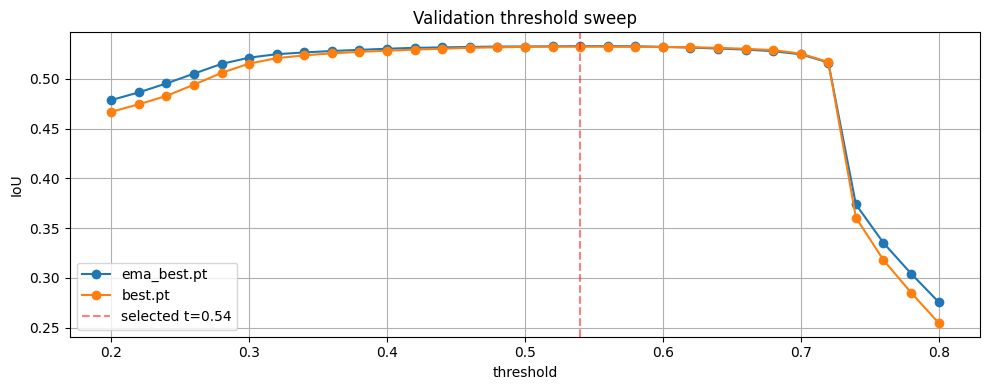

In [16]:

thresholds = [round(x, 2) for x in np.arange(0.20, 0.81, 0.02)]
ckpt_candidates = []
for name in ['best.pt', 'ema_best.pt']:
    p = CKPT_DIR / name
    if p.exists():
        ckpt_candidates.append(p)

if not ckpt_candidates:
    raise FileNotFoundError(f'No checkpoints found in {CKPT_DIR}')

results = []
for ckpt_path in ckpt_candidates:
    print('\n' + '=' * 100)
    print('checkpoint:', ckpt_path)
    model, ckpt, ckpt_vocab = load_checkpoint(
        ckpt_path,
        device,
        model_kwargs={'rover_emb_dim': cfg['rover_emb_dim'], 'rover_cond_dim': cfg['rover_cond_dim']},
    )

    if ckpt_vocab != rover_vocab:
        print('warning: checkpoint rover_vocab differs from loaded rover_vocab, using checkpoint vocab for this run')
        rover_vocab = ckpt_vocab
        ds_val.rover_vocab = rover_vocab
        ds_test.rover_vocab = rover_vocab

    val_probs, val_gt = collect_probs_and_gt(
        model,
        loader_val,
        cache_prefix=ckpt_path.stem,
        cache_dir=RUN_DIR / 'val_cache',
    )
    print('val_probs shape:', tuple(val_probs.shape))
    print('val_gt shape   :', tuple(val_gt.shape))

    best_t, best_iou, sweep_df = choose_best_threshold_from_probs(val_probs, val_gt, thresholds)
    sweep_path = RUN_DIR / f'{ckpt_path.stem}_val_sweep.csv'
    sweep_df.to_csv(sweep_path, index=False)
    print(f'best threshold for {ckpt_path.name}: {best_t:.2f} | IoU={best_iou:.6f}')

    results.append({
        'checkpoint': ckpt_path.name,
        'checkpoint_path': str(ckpt_path),
        'best_t': float(best_t),
        'best_iou': float(best_iou),
    })

results_df = pd.DataFrame(results).sort_values(['best_iou', 'checkpoint'], ascending=[False, True]).reset_index(drop=True)
display(results_df)

selected = results_df.iloc[0].to_dict()
selected_path = Path(selected['checkpoint_path'])
selected_threshold = float(selected['best_t'])
selected_name = selected_path.stem

# Prefer EMA if tied on IoU
if len(results_df) > 1:
    top_iou = results_df.iloc[0]['best_iou']
    tied = results_df[results_df['best_iou'] == top_iou].copy()
    if len(tied) > 1:
        ema_rows = tied[tied['checkpoint'].str.contains('ema', case=False, na=False)]
        if len(ema_rows):
            selected = ema_rows.iloc[0].to_dict()
            selected_path = Path(selected['checkpoint_path'])
            selected_threshold = float(selected['best_t'])
            selected_name = selected_path.stem

with open(RUN_DIR / 'selected_checkpoint.json', 'w') as f:
    json.dump({
        'selected_checkpoint': selected['checkpoint'],
        'selected_path': selected['checkpoint_path'],
        'best_t': selected_threshold,
        'best_iou': float(selected['best_iou']),
    }, f, indent=2, ensure_ascii=False)

print('\nselected checkpoint:', selected['checkpoint'])
print('selected threshold :', selected_threshold)
print('selected val iou   :', selected['best_iou'])

fig, ax = plt.subplots(figsize=(10, 4))
for ckpt_name in results_df['checkpoint'].tolist():
    df = pd.read_csv(RUN_DIR / f'{Path(ckpt_name).stem}_val_sweep.csv')
    ax.plot(df['threshold'], df['iou'], marker='o', label=ckpt_name)
ax.axvline(selected_threshold, color='red', linestyle='--', alpha=0.5, label=f'selected t={selected_threshold:.2f}')
ax.set_xlabel('threshold')
ax.set_ylabel('IoU')
ax.set_title('Validation threshold sweep')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [17]:

selected_ckpt_path = Path(selected['checkpoint_path'])
selected_model, selected_ckpt, _ = load_checkpoint(
    selected_ckpt_path,
    device,
    model_kwargs={'rover_emb_dim': cfg['rover_emb_dim'], 'rover_cond_dim': cfg['rover_cond_dim']},
)

print('using selected checkpoint for test:', selected_ckpt_path.name)

test_probs = predict_test_probs(
    selected_model,
    loader_test,
    cache_prefix=selected_ckpt_path.stem,
    cache_dir=RUN_DIR / 'test_cache',
)
print('test_probs shape:', tuple(test_probs.shape))

pred_dir = RUN_DIR / 'predicted_static_grids'
save_predictions(test_probs, selected_threshold, ds_test.info if hasattr(ds_test, 'info') else load_info_with_root(DATA_TEST, 'test'), pred_dir)

# sanity checks
saved = sorted(pred_dir.glob('*.npy'))
assert len(saved) == len(ds_test), (len(saved), len(ds_test))
for p in saved[:5]:
    arr = np.load(p)
    assert arr.shape == (1, BEV_H, BEV_W), arr.shape
    assert set(np.unique(arr).tolist()) <= {0, 1}, np.unique(arr)
print(f'predictions saved: {len(saved)} files')


loaded ema_best.pt: missing=0 unexpected=0
using selected checkpoint for test: ema_best.pt
loading cache: ema_best_test_probs.pt
test_probs shape: (2000, 1, 188, 126)


save npy t=0.54: 100%|██████████| 2000/2000 [00:39<00:00, 50.05it/s]

predictions saved: 2000 files


In [18]:
sleected_threshold

NameError: name 'sleected_threshold' is not defined

In [19]:
selected_threshold

0.54

In [20]:
from pathlib import Path
import json
import zipfile
import hashlib
import numpy as np
import pandas as pd
import torch

# Ожидается, что эти переменные уже есть после предыдущих ячеек:
# test_probs, RUN_DIR, selected_name, selected_threshold, BEV_H, BEV_W, DATA_TEST
# Если test_info у тебя не задан, возьмём из ds_test.info
test_info = globals().get("test_info", None)
if test_info is None:
    test_info = ds_test.info if hasattr(ds_test, "info") else load_info_with_root(DATA_TEST, "test")

# Подбери список threshold'ов как хочешь
thresholds_to_try = sorted(set([
    0.65,
    0.7,
    0.75,
    0.8,
    0.85
]))
thresholds_to_try = [t for t in thresholds_to_try if 0.05 <= t <= 0.95]

print("thresholds_to_try:", thresholds_to_try)

def _pred_name_from_row(row):
    if 'predicted_occupancy_grid' in row:
        return Path(row['predicted_occupancy_grid']).name
    if 'predicted_static_grid' in row:
        return Path(row['predicted_static_grid']).name
    return f"{int(row.name)}.npy"

def _save_preds_for_threshold(test_probs, threshold, out_dir, test_info):
    out_dir.mkdir(parents=True, exist_ok=True)
    for p in out_dir.glob("*.npy"):
        p.unlink()

    preds = (test_probs > threshold).numpy().astype(np.int32)
    assert len(preds) == len(test_info), (len(preds), len(test_info))

    for i, row in test_info.iterrows():
        fname = _pred_name_from_row(row)
        np.save(out_dir / fname, preds[i].reshape(1, BEV_H, BEV_W))

    # sanity check
    files = sorted(out_dir.glob("*.npy"))
    assert len(files) == len(test_info), (len(files), len(test_info))
    for p in files[:3]:
        arr = np.load(p)
        assert arr.shape == (1, BEV_H, BEV_W), arr.shape
        assert set(np.unique(arr).tolist()) <= {0, 1}, np.unique(arr)

def _build_zip(pred_dir, zip_path):
    if zip_path.exists():
        zip_path.unlink()

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        zf.write(DATA_TEST / "info.csv", arcname="info.csv")
        for npy in sorted(pred_dir.glob("*.npy")):
            zf.write(npy, arcname=f"predicted_static_grids/{npy.name}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        bad = zf.testzip()
        assert bad is None, f"Bad zip entry: {bad}"
        n_entries = len(zf.namelist())

    h = hashlib.sha256()
    with open(zip_path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)

    return {
        "zip": str(zip_path.resolve()),
        "entries": n_entries,
        "sha256": h.hexdigest(),
        "size_mb": round(zip_path.stat().st_size / 1e6, 3),
    }

results = []
base_dir = RUN_DIR / "threshold_submissions"
base_dir.mkdir(parents=True, exist_ok=True)

for t in thresholds_to_try:
    print("\n" + "=" * 100)
    print(f"building submission for threshold={t:.2f}")

    pred_dir = base_dir / f"predicted_static_grids_t_{t:.2f}"
    zip_path = base_dir / f"submission_{selected_name}_t_{t:.2f}.zip"

    _save_preds_for_threshold(test_probs, t, pred_dir, test_info)
    meta = _build_zip(pred_dir, zip_path)
    meta["threshold"] = float(t)
    results.append(meta)

results_df = pd.DataFrame(results)
display(results_df)


thresholds_to_try: [0.65, 0.7, 0.75, 0.8, 0.85]

building submission for threshold=0.65

building submission for threshold=0.70

building submission for threshold=0.75

building submission for threshold=0.80

building submission for threshold=0.85


,zip,entries,sha256,size_mb,threshold
0,/home/jupyter/project/runs/v4_cleaned_aug_smoo...,2001,cf97a88cef012cde3b965d3048837181a492c4419b1e64...,2.879,0.65
1,/home/jupyter/project/runs/v4_cleaned_aug_smoo...,2001,825a03af2ac80e36b036ade3b6915d2da9c1c3a01bfcf5...,3.209,0.70
2,/home/jupyter/project/runs/v4_cleaned_aug_smoo...,2001,0c3cdeff6e8cab8683857f15abef6c203747f77f5eec0a...,2.213,0.75
3,/home/jupyter/project/runs/v4_cleaned_aug_smoo...,2001,663b8a69c799411a0f2dbf18df769d3c4579e598371e94...,1.709,0.80
4,/home/jupyter/project/runs/v4_cleaned_aug_smoo...,2001,5320975ece2e3ed98641a4c3c51033d7b6302dfbccc048...,1.489,0.85
